In [ ]:
# Analysis of simulated trajectorories

In [53]:
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [3]:
#Read and subset tracker data
df = pd.read_csv('../input/Osker-X2.csv', sep=';')
df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
ds = xr.Dataset.from_dataframe(df)
ds_daily = ds.groupby("time.date").first() #Daily subset
ds_3day = ds_daily.isel(date=slice(0, None, 3)) #3-daily subset

/tmp/ipykernel_3179/460691332.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [13]:
sim = xr.open_dataset('../results/juliette_glorys_windglophynrt.nc')
sim

<xarray.Dataset> Size: 64MB
Dimensions:                                   (trajectory: 220, time: 1729)
Coordinates:
  * trajectory                                (trajectory) int32 880B 0 ... 219
  * time                                      (time) datetime64[ns] 14kB 2025...
Data variables: (12/39)
    status                                    (trajectory, time) float64 3MB ...
    moving                                    (trajectory, time) float64 3MB ...
    age_seconds                               (trajectory, time) float32 2MB ...
    origin_marker                             (trajectory, time) float64 3MB ...
    lon                                       (trajectory, time) float32 2MB ...
    lat                                       (trajectory, time) float32 2MB ...
    ...                                        ...
    sea_water_salinity                        (trajectory, time) float32 2MB ...
    sea_ice_area_fraction                     (trajectory, time) float32 2MB ...
    sea_ice_thickness                         (trajectory, time) float32 2MB ...
    sea_ice_x_velocity                        (trajectory, time) float32 2MB ...
    sea_ice_y_velocity                        (trajectory, time) float32 2MB ...
    land_binary_mask                          (trajectory, time) float32 2MB ...
Attributes: (12/147)
    Conventions:                                                           CF...
    standard_name_vocabulary:                                              CF...
    featureType:                                                           tr...
    title:                                                                 Op...
    summary:                                                               Ou...
    keywords:                                                              tr...
    ...                                                                    ...
    geospatial_lon_units:                                                  de...
    geospatial_lon_resolution:                                             point
    runtime:                                                               0:...
    geospatial_vertical_min:                                               nan
    geospatial_vertical_max:                                               nan
    geospatial_vertical_positive:                                          up

In [ ]:
def colour_finder(sim_in,by='reader_'):
    #pick colormap
    cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
    colors = cmap(np.linspace(0, 1, 20))#20 colors
    if by=='reader_x_sea_water_velocity': 
        val = sim_in.reader_x_sea_water_velocity
    return col_dict

In [38]:
dssim.lon[traj].dropna(dim="time")

<xarray.DataArray 'lon' (time: 49)> Size: 196B
array([-70.72626 , -70.73659 , -70.74662 , -70.75635 , -70.7658  , -70.77501 ,
       -70.784   , -70.79277 , -70.80122 , -70.809364, -70.8172  , -70.824745,
       -70.832016, -70.83902 , -70.845764, -70.852264, -70.85853 , -70.864586,
       -70.870445, -70.876114, -70.88157 , -70.88685 , -70.891975, -70.896965,
       -70.90185 , -70.90663 , -70.91074 , -70.91417 , -70.91692 , -70.91901 ,
       -70.92041 , -70.92114 , -70.921196, -70.92061 , -70.919365, -70.91747 ,
       -70.91493 , -70.91174 , -70.9079  , -70.90341 , -70.89827 , -70.89248 ,
       -70.88604 , -70.87896 , -70.87123 , -70.86287 , -70.85387 , -70.84422 ,
       -70.833954], dtype=float32)
Coordinates:
  * time        (time) datetime64[ns] 392B 2025-12-03T00:00:31 ... 2025-12-05...
    trajectory  int32 4B 219
Attributes:
    units:          degrees_east
    standard_name:  longitude
    long_name:      longitude
    axis:           X
    minval:         nan
    maxval:         nan

In [45]:


import glob

glob.glob("../results/*.nc")



['../results/juliette_topaz4_windglophynrt.nc',
 '../results/juliette_glophyanfc_windglophynrt.nc',
 '../results/juliette_glorys_windglophynrt.nc',
 '../results/juliette_topaz5_windglophynrt.nc']

0 ../results/juliette_topaz4_windglophynrt.nc [0.12156863 0.46666667 0.70588235 1.        ]
1 ../results/juliette_glophyanfc_windglophynrt.nc [0.68235294 0.78039216 0.90980392 1.        ]
2 ../results/juliette_glorys_windglophynrt.nc [1.         0.49803922 0.05490196 1.        ]
3 ../results/juliette_topaz5_windglophynrt.nc [1.         0.73333333 0.47058824 1.        ]


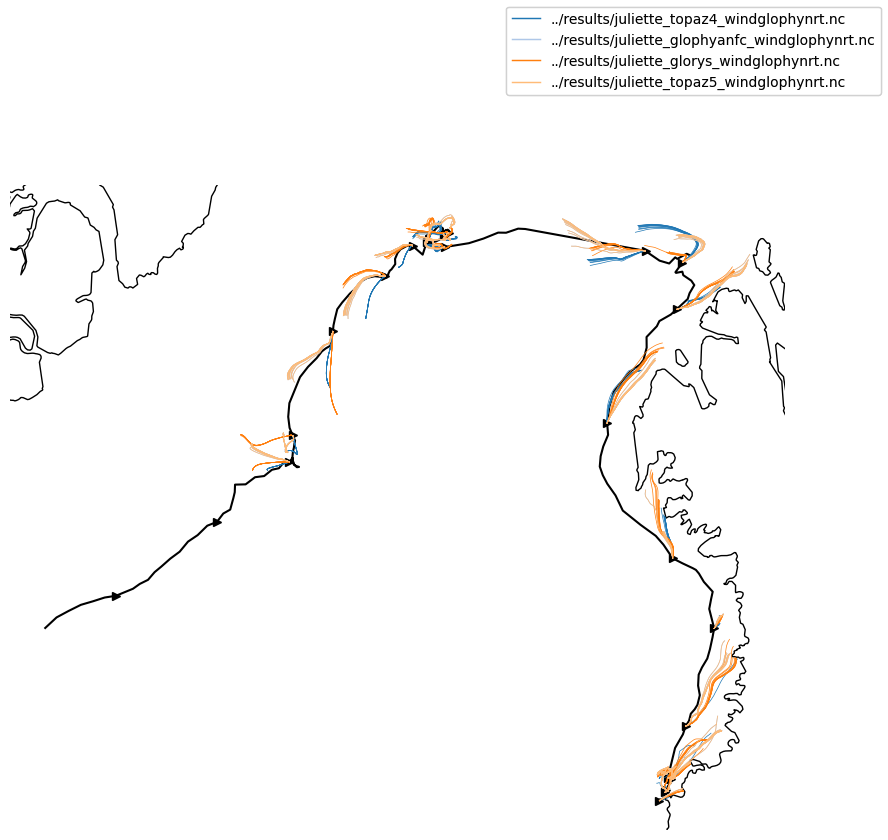

In [58]:
# Map plot

#def
#by = inputdataidx
cmap = plt.get_cmap('tab20')  # or 'viridis', 'plasma', etc.
col = cmap(np.linspace(0, 1, 20))#20 colors

#Figure
fig,ax = plt.subplots(1,1,figsize=(10,10),subplot_kw={'projection':ccrs.NorthPolarStereo()})#central_longitude=20})
ax.coastlines(resolution='10m')
trans = ccrs.PlateCarree()
#ax.set_extent((-42.5, -11, 65, 78))

# plot obs
ax.plot(ds_3day['lon'],ds_3day['lat'],'>',transform=trans,color='k')
ax.plot(ds['lon'],ds['lat'],transform=trans,color='k',label='Observation')

# plot sim
simfile_l = glob.glob("../results/*.nc")#['../results/juliette_glorys_windglophynrt.nc',]
for inputdataidx, inputdata in enumerate(simfile_l):
    print(inputdataidx, inputdata, col[inputdataidx])
    dssim = xr.open_dataset(inputdata)
    for traj in dssim.trajectory: #goes trhough trajectories with different coefficients, size, time and position
        ax.plot(dssim.lon[traj].dropna(dim="time"),dssim.lat[traj].dropna(dim="time"),
                color=col[inputdataidx],linewidth=0.5,
                transform=trans)
#legend
legend_elements = [Line2D([0], [0],linestyle='-', color=col[idx], lw=1,label=simfile_l[idx]) for idx in range(inputdataidx+1)]
leg = fig.legend(handles=legend_elements,)#fontsize=fs,ncol=len(legend_elements0+legend_elements2),                  columnspacing=0.6,labelspacing=0.3,loc='center',bbox_to_anchor=bbox_dict[kw][0])
plt.axis('off')
fig.add_artist(leg)
#plt.savefig('../results/fig_map.png',dpi=200,transparent=True,bbox_inches='tight')
plt.show()